In [ ]:
%load_ext autoreload
%autoreload 2
# %matplotlib inline

import os

# to allow deterministic gradients on CUDA
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

while 'notebooks' in os.getcwd():
    os.chdir("../")

# !pwd

import torch
from torch import nn, einsum

# determnistic = True
determnistic = False  # doesn't always work with some layers
torch.use_deterministic_algorithms(determnistic)
torch.backends.cudnn.deterministic = determnistic

import quantus
import gc
import torch.nn.functional as F

from lib.helpers import plot_example_grid, perturb_batch_with_random_patches
from lib.attributions import GradientAscentDiff, PullbackAscentDiff, \
    quantus_pullback_ascent_diff_explain_func
from lib.setup import setup_notebook
from lib.defaults import get_default_kwargs
from lib.surrogates import LayerNorm2d, PVTAttention, soften_module_inplace_, set_module_standard_backward_
from lib.evaluator import QuantusEvaluator, default_explainers, default_metrics


batch_size = 10
model_name = "resnet50"
# model_name = "vgg11_bn"
model_source = "torchvision"

# model_name = "pvt_v2_b1"
# model_source = "timm"
dataset = "imagenet"
# dataset = "imagenette"

seed = 314

device, loader, model = setup_notebook(batch_size=batch_size, model_name=model_name, model_source=model_source, seed=seed, dataset=dataset)

it = iter(loader)
images, labels = next(it)

x_batch = images.numpy()
y_batch = labels.numpy()
images = images.to(device)
labels = labels.to(device)

n_show = 15

# print(len(loader.dataset))
print(images.min(), images.max(), images.mean(), images.std())
print(f"images.shape = {images.shape}")
print(f"labels = {labels[:n_show].tolist()}")

plot_example_grid(images[:n_show], nrow=min(5, n_show))

In [2]:
if model_name.startswith("resnet"):
    gc_layer = model[1].layer4[-1].conv3
elif model_name.startswith("vgg"):
    gc_layer = model[1].avgpool
elif model_name.startswith("pvt"):
    # gc_layer = model[1].stages[-1].blocks[-1].norm2  # rises error 
    gc_layer = None
    
# gc_layer = None

In [3]:
gc_layer

Conv2d(512, 2048, kernel_size=(1, 1), stride=(1, 1), bias=False)

In [4]:
temperatures, pga_kwargs_counterfactual, pga_kwargs_grad, pga_kwargs_adv = get_default_kwargs()

# alpha = 20
# K = 5

# pga_kwargs_counterfactual = {**pga_kwargs_counterfactual, "alpha": alpha, "steps": K}

# modify the model in-place, but don't change its backward behavior
soften_module_inplace_(model, temperatures=temperatures, standard_backward=True, fill_default_temperatures=True)

# set_module_standard_backward_(model, standard_backward=True)

gad = GradientAscentDiff(model, **pga_kwargs_counterfactual)
gad_adv = GradientAscentDiff(model, **pga_kwargs_adv)
grad = GradientAscentDiff(model, **pga_kwargs_grad)

pad = PullbackAscentDiff(model, **pga_kwargs_counterfactual)
sp = PullbackAscentDiff(model, **pga_kwargs_grad)

# explainer_list = ["PullbackAscent3", "SoftPullback", "PullbackAscent", "SmoothPullback", "FusionPullback", "Gradient", "GradientAscent", "SmoothGrad", "FusionGrad", "GradientShap", "IntegratedGradients", "DeepLift", "GuidedGradCam"]
explainer_list = ["PullbackAscent", "SoftPullback"]
explainers = default_explainers(explainer_list, gc_layer=gc_layer, reduce_axes=False)

metrics = default_metrics(["infidelity"])

# metrics = default_metrics()

In [5]:
# model
# explainers

In [6]:
evaluator = QuantusEvaluator(
    model,
    metrics,
    explainers,
    device=device,
)

In [7]:
evaluator.precompute_attributions(x_batch, y_batch)
# evaluator.precompute_attributions(x_batch, preds)

Precomputing attributions for explainer PullbackAscent
Explainer PullbackAscent took 0.871 seconds.
Precomputing attributions for explainer SoftPullback
Explainer SoftPullback took 0.159 seconds.


In [8]:
attrs = {name: torch.as_tensor(attr) for name, attr in evaluator.attributions.items()}

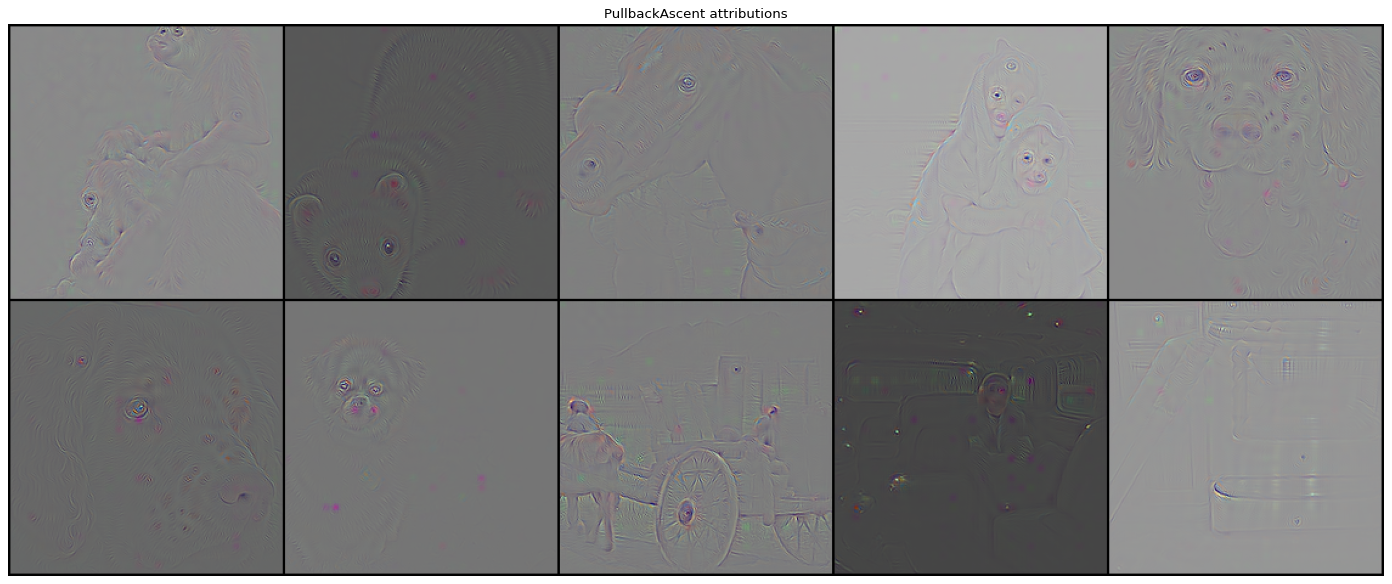

In [9]:
plot_example_grid(attrs["PullbackAscent"][:n_show], nrow=min(5, n_show), title="PullbackAscent attributions", heatmap=False)

In [10]:
results = evaluator.evaluate_loader(loader, n_batches=1)
# results = evaluator.evaluate_batch(x_batch, y_batch, precompute_attributions=True)
# results = evaluator.evaluate_batch(x_batch, preds, precompute_attributions=False)

Evaluating batch 1/1
Precomputing attributions for explainer PullbackAscent
Explainer PullbackAscent took 0.610 seconds.
Precomputing attributions for explainer SoftPullback
Explainer SoftPullback took 0.153 seconds.
Evaluating metric infidelity with explainer PullbackAscent


10it [00:09,  1.05it/s]                


Evaluating metric infidelity with explainer SoftPullback


10it [00:08,  1.12it/s]                


In [11]:
df = evaluator.as_dataframe(results)
df

,infidelity
PullbackAscent,"[2.0329977263571344, 2.273944530326389, 11.384..."
SoftPullback,"[2.738471857631721, 1.6198169661057273, 12.852..."


In [12]:
summary = evaluator.summarize_results(df, quantile=0.0)
summary

,infidelity
PullbackAscent,5.309±2.92
SoftPullback,5.51±3.34
